In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prithivsakthiur/deepfake-vs-real-60k")

print("Path to dataset files:", path)

C:\Users\hieul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\hieul\.cache\kagglehub\datasets\prithivsakthiur\deepfake-vs-real-60k\versions\1


In [25]:
# Import necessary libraries
import numpy as np                                 # for numerical computations
import pandas as pd                                # for data manipulation

# Import PyTorch libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50

# Import image processing and evaluation libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_fscore_support, roc_curve, auc
from PIL import Image
import os
import random
from tqdm import tqdm
import json
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [ ]:
# Device config (prefer GPU, else CPU by default)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define data directory (robust to Kaggle vs local paths)
# Prefer the `path` variable returned by kagglehub if present, else try common locations
dataset_dir = globals().get('path') or "/kaggle/input/deepfake-vs-real-60k/deepfake-vs-real-60k"
if not os.path.exists(dataset_dir):
    # Try a relative folder in the workspace
    candidate = os.path.join(os.getcwd(), 'deepfake-vs-real-60k')
    if os.path.exists(candidate): # If found, use it
        dataset_dir = candidate
    else:                         # Else search entire workspace
        print(f"Warning: dataset_dir {dataset_dir!r} not found. Searching workspace for dataset folder...")
        found = None
        for root, dirs, files in os.walk(os.getcwd()):
            if 'deepfake-vs-real-60k' in dirs:
                found = os.path.join(root, 'deepfake-vs-real-60k')
                break
        if found:
            dataset_dir = found
            print('Found dataset at', dataset_dir)
        else:
            raise FileNotFoundError('Dataset directory not found. Please set `dataset_dir` to the correct path.')
print('Using dataset_dir:', dataset_dir)

Using device: cuda
Using dataset_dir: C:\Users\hieul\.cache\kagglehub\datasets\prithivsakthiur\deepfake-vs-real-60k\versions\1


In [31]:
print("Dataset structure:")
for root, dirs, files in os.walk(dataset_dir):                       # Walk through the dataset directory
    level = root.replace(dataset_dir, '').count(os.sep)              # Determine the level of depth in the directory
    indent = ' ' * 2 * level                                         # Create indentation based on level
    print(f"{indent}{os.path.basename(root)}/")                      # Print the directory name
    subindent = ' ' * 2 * (level + 1)                                # Indentation for files
    for file in files[:5]:                                           # Limit to first 5 files for brevity
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files)-5} more files")

Dataset structure:
1/
  deepfake-vs-real-60k/
    Fake/
      0001 (1).jpg
      0001 (10).jpg
      0001 (100).jpg
      0001 (1000).jpg
      0001 (10000).jpg
      ... and 28591 more files
    Real/
      0001 (1).png
      0001 (10).png
      0001 (100).png
      0001 (1000).png
      0001 (10000).png
      ... and 28470 more files


In [5]:
# Transformations for training data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),                                              # Flip the image horizontally with a probability of 0.5 to augment the dataset
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Randomly change the brightness, contrast, and saturation of the image to make the model robust to lighting variations
    transforms.RandomRotation(5),                                                   # Randomly rotate the image by up to 5 degrees to help the model generalize better                                       
    transforms.ToTensor()
])

# Transformations for test data
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])      

In [6]:
# Define dataset class
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir                                                        # Root directory containing images
        self.transform = transform                                                      # Transformations to apply to images 
        self.image_paths = []                                                           # List to store image file paths
        self.labels = []                                                                # List to store corresponding labels

        # Load image paths and labels
        for label in os.listdir(root_dir):
            label_dir = os.path.join(root_dir, label)                                   # Join root directory with label subdirectory to get full path
            if os.path.isdir(label_dir):
                for img_file in os.listdir(label_dir):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(label_dir, img_file))      # Append full image path to image list
                        self.labels.append(1 if label == 'Fake' else 0)             # Assign label: 1 for 'Fake', 0 for 'Real'

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [7]:
# Define dataset
dataset_root_dir = os.path.join(dataset_dir, 'deepfake-vs-real-60k')
full_dataset = DeepfakeDataset(root_dir=dataset_root_dir, transform=train_transform)
train_size = int(0.7 * len(full_dataset))                          # 70% for training
val_size = int(0.15 * len(full_dataset))                           # 15% for validation
test_size = len(full_dataset) - train_size - val_size              # 15% for testing
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]                # Split the dataset into training, validation, and testing sets
)

print(f"Dataset root: {dataset_root_dir}")
print(f"Total images: {len(full_dataset)}")
classes = [d for d in os.listdir(dataset_root_dir) if os.path.isdir(os.path.join(dataset_root_dir, d))]
print(f"Classes: {classes}")

Dataset root: C:\Users\hieul\.cache\kagglehub\datasets\prithivsakthiur\deepfake-vs-real-60k\versions\1\deepfake-vs-real-60k
Total images: 57071
Classes: ['Fake', 'Real']


In [8]:
# Load data loaders
# NOTE: On Windows/Jupyter, num_workers > 0 can silently hang or appear "stuck".
batch_size = 32

is_windows = os.name == "nt"
num_workers = 0 if is_windows else 2
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)

print(f"DataLoader config -> batch_size={batch_size}, num_workers={num_workers}, pin_memory={pin_memory}")


DataLoader config -> batch_size=32, num_workers=0, pin_memory=True


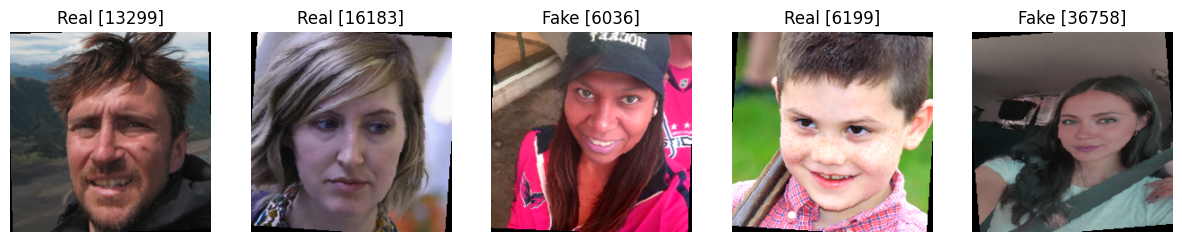

In [ ]:
def visualise_samples(dataset, num_samples=5):

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))     # Create subplots for displaying images
    indices = random.sample(range(len(dataset)), num_samples)     # Randomly select sample indices from the dataset
    for i in range(num_samples):
        img, label = dataset[indices[i]]
        img = img.permute(1, 2, 0).numpy()  # Convert from Tensor to NumPy array and rearrange dimensions (height, width, channels)
        axes[i].imshow(img)
        axes[i].set_title(f'{"Fake" if label == 1 else "Real"} [{indices[i]}]')
        axes[i].axis('off')
    plt.show()

visualise_samples(train_dataset)

In [ ]:
# Build network using model from torchvision (Resnet50)
class DeepfakeClassifier(nn.Module):
    def __init__(self, numclasses: int = 2, freeze_backbone: bool = False, model_name='resnet50'):
        super(DeepfakeClassifier, self).__init__()

        if model_name == 'resnet50':
            self.backbone = resnet50(pretrained=True)                                   # Load pre-trained ResNet50 model
            num_features = self.backbone.fc.in_features                                 # Get number of input features to the final fully connected layer
            self.backbone.fc = nn.Identity()                                            # Remove the final classification layer
        else:
            raise ValueError("Unsupported model name")
        
        self.classifier = nn.Sequential(                                     # Define classifier layer
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, numclasses)
        )

        if freeze_backbone:                                                 # Freeze backbone parameters if specified
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)                                           # Extract features using the base model
        return self.classifier(features)                                   # Classify using the classifier

In [11]:
# Instantiate the model
model = DeepfakeClassifier(numclasses=2, model_name='resnet50').to(device)  # Instantiate the model and move it to the specified device
print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters")
# Define loss function and optimizer
loss_function = nn.CrossEntropyLoss()                                      # Cross-entropy loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.0001)                  # Adam optimizer with learning rate 0.0001


C:\Users\hieul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\hieul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model initialized with 24033090 parameters


In [ ]:
def _run_epoch(model, loader, loss_fn, optimizer=None, device=None, desc="train"):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for step, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        bs = labels.size(0)
        total_loss += loss.item() * bs
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += bs

        # You see progress immediately
        if step == 0:
            pbar.set_postfix(loss=float(loss.item()), acc=float(correct / total))

    return total_loss / max(total, 1), correct / max(total, 1)


def train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=2, device=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1.0
    best_state = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}", flush=True)

        train_loss, train_acc = _run_epoch(
            model, train_loader, loss_fn, optimizer=optimizer, device=device,
            desc=f"Train {epoch+1}/{num_epochs}"
        )
        val_loss, val_acc = _run_epoch(
            model, val_loader, loss_fn, optimizer=None, device=device,
            desc=f"Val   {epoch+1}/{num_epochs}"
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Train -> loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
            f"Val -> loss: {val_loss:.4f}, acc: {val_acc:.4f}",
            flush=True
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return history, best_state


In [13]:
images, labels = next(iter(train_loader))
print(images.shape, labels[:10])

with torch.no_grad():
    out = model(images.to(device))
print(out.shape)  # should be (batch_size, 2)

torch.Size([32, 3, 224, 224]) tensor([1, 1, 1, 1, 1, 0, 1, 0, 1, 1])
torch.Size([32, 2])


In [30]:
# Train model
training_history, best_state = train_model(model, train_loader, val_loader, loss_function, optimizer, num_epochs=2, device=device)


Epoch 1/2


Train -> loss: 0.0038, acc: 0.9989 | Val -> loss: 0.0012, acc: 0.9994

Epoch 2/2


Train -> loss: 0.0050, acc: 0.9988 | Val -> loss: 0.0005, acc: 0.9999


In [17]:
# Evaluation function
def evaluate_model(model, test_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).long()

            outputs = model(images)                 # (B, 2)
            loss = loss_fn(outputs, labels)

            bs = labels.size(0)
            total_loss += loss.item() * bs
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += bs

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, digits=4)

    return avg_loss, acc, cm, report

In [18]:
test_loss, test_acc, cm, report = evaluate_model(model, test_loader, loss_function, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", report)

Test loss: 0.0064
Test acc : 0.9986
Confusion matrix:
 [[4225    4]
 [   8 4325]]

Classification report:
               precision    recall  f1-score   support

           0     0.9981    0.9991    0.9986      4229
           1     0.9991    0.9982    0.9986      4333

    accuracy                         0.9986      8562
   macro avg     0.9986    0.9986    0.9986      8562
weighted avg     0.9986    0.9986    0.9986      8562



In [20]:
# Visualize confusion matrix
def collect_test_results(model, test_loader, device, num_classes=2):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).long()

            logits = model(images)                          # (B, C)
            probs = torch.softmax(logits, dim=1)            # (B, C)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    probabilities = np.concatenate(all_probs, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    preds = probabilities.argmax(axis=1)

    accuracy = accuracy_score(labels, preds)

    # For binary, use standard precision/recall/f1 for positive class (=1).
    # For multi-class, use macro averaging.
    avg = "binary" if num_classes == 2 else "macro"
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=avg, zero_division=0)

    # ROC-AUC: only meaningful for binary and needs probability of positive class
    if num_classes == 2:
        try:
            roc_auc = roc_auc_score(labels, probabilities[:, 1])
        except ValueError:
            roc_auc = float("nan")
    else:
        roc_auc = float("nan")

    cm = confusion_matrix(labels, preds)

    evaluation_results = {
        "labels": labels,
        "predictions": preds,
        "probabilities": probabilities,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "confusion_matrix": cm
    }
    return evaluation_results

In [21]:
num_classes = 2
class_names = ["real", "deepfake"]  # adjust if your mapping differs

evaluation_results = collect_test_results(model, test_loader, device, num_classes=num_classes)
print("Test accuracy:", evaluation_results["accuracy"])
print("Confusion matrix:\n", evaluation_results["confusion_matrix"])

Test accuracy: 0.9988320485867788
Confusion matrix:
 [[4226    3]
 [   7 4326]]


In [32]:
# Plot training and evaluation results
def plot_training_and_eval(training_history, evaluation_results, class_names, is_binary=True):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # --- Loss curves ---
    ax1.plot(training_history["train_loss"], label="Training Loss")
    ax1.plot(training_history["val_loss"], label="Validation Loss")
    ax1.set_title("Training and Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # --- Accuracy curves ---
    ax2.plot(training_history["train_acc"], label="Training Accuracy")
    ax2.plot(training_history["val_acc"], label="Validation Accuracy")
    ax2.set_title("Training and Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    # --- ROC (binary only) ---
    if is_binary:
        fpr, tpr, _ = roc_curve(evaluation_results["labels"], evaluation_results["probabilities"][:, 1])
        roc_auc = auc(fpr, tpr)

        ax3.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
        ax3.plot([0, 1], [0, 1], lw=2, linestyle="--")
        ax3.set_xlim([0.0, 1.0])
        ax3.set_ylim([0.0, 1.05])
        ax3.set_xlabel("False Positive Rate")
        ax3.set_ylabel("True Positive Rate")
        ax3.set_title("Receiver Operating Characteristic (ROC) Curve")
        ax3.legend(loc="lower right")
        ax3.grid(True)
    else:
        ax3.axis("off")
        ax3.text(0.5, 0.5, "ROC Curve\n(Multi-class)", ha="center", va="center", fontsize=16)

    # --- Class distribution in test set ---
    labels = evaluation_results["labels"]
    class_counts = [int(np.sum(labels == i)) for i in range(len(class_names))]
    ax4.bar(class_names, class_counts)
    ax4.set_title("Test Set Class Distribution")
    ax4.set_xlabel("Class")
    ax4.set_ylabel("Count")
    ax4.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

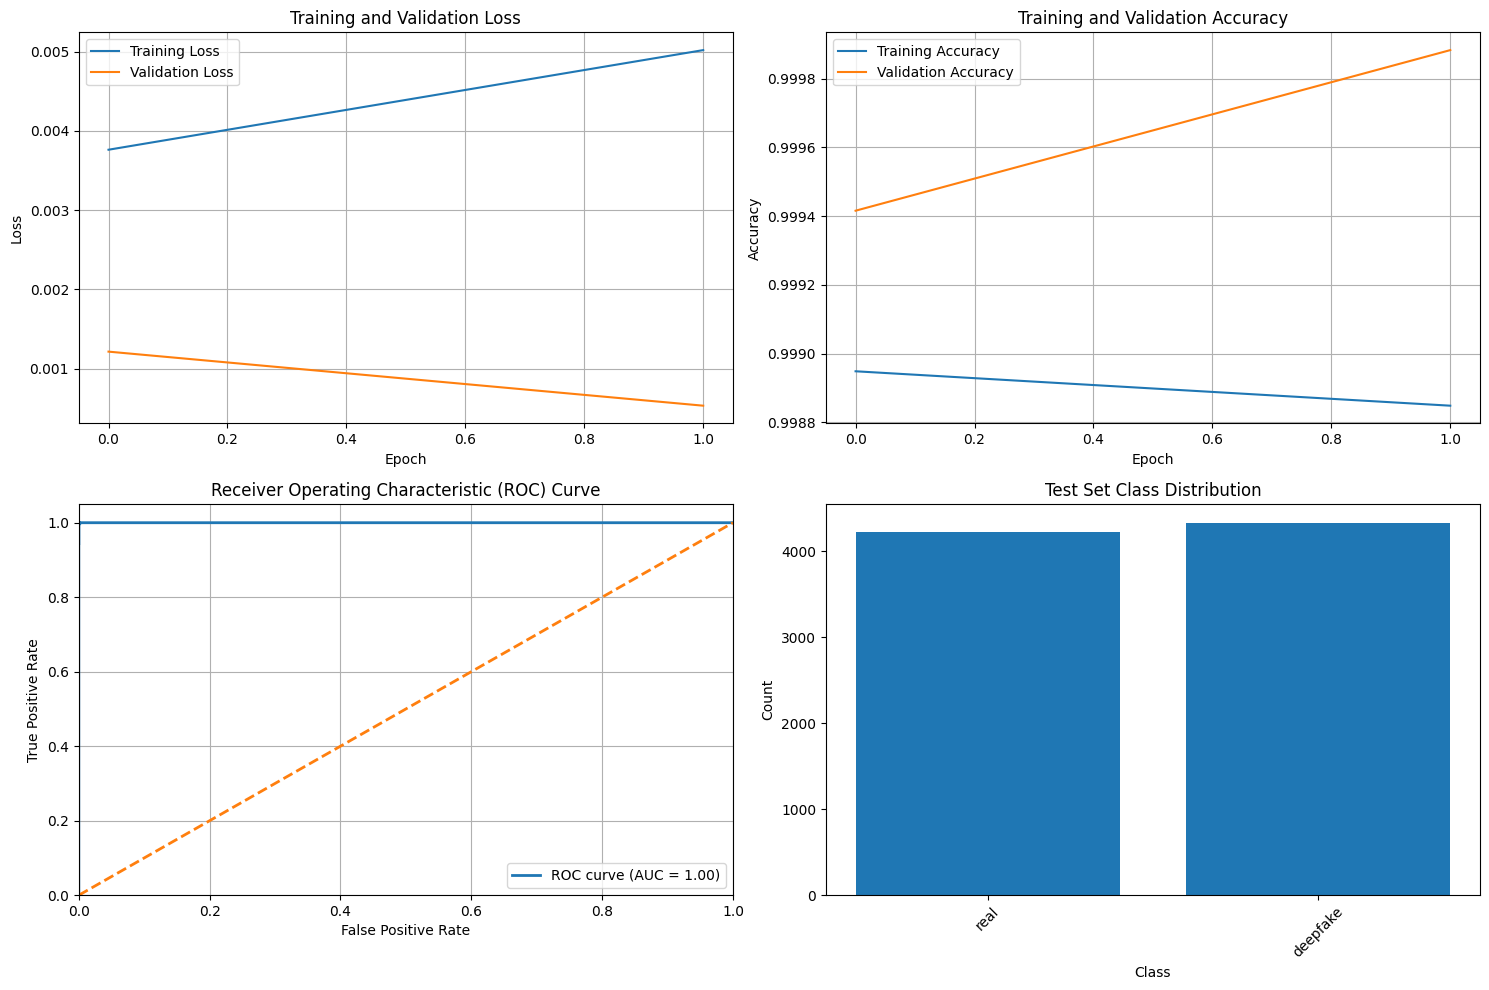

In [33]:
is_binary = (num_classes == 2)
plot_training_and_eval(training_history, evaluation_results, class_names, is_binary=(num_classes==2))